In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    r"C:\Users\Hp\Desktop\Travel-Tourism-Customer-Retention-Analysis\data\processed\hotel_bookings_feature_engineered.csv"
)

df.shape

(87370, 36)

In [3]:
df['adr'].describe()

count    87370.000000
mean       106.346935
std         55.004259
min         -6.380000
25%         72.000000
50%         98.100000
75%        134.000000
max       5400.000000
Name: adr, dtype: float64

## ADR Before Treatment

Extreme ADR values were detected during Day 4 analysis.

These values may distort statistical analysis and machine learning models.

In [4]:
Q1 = df['adr'].quantile(0.25)

Q3 = df['adr'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)

upper_bound = Q3 + (1.5 * IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -21.0
Upper Bound: 227.0


In [5]:
outliers_before = df[
    (df['adr'] < lower_bound) |
    (df['adr'] > upper_bound)
]

print("Outliers Before Treatment:", len(outliers_before))

Outliers Before Treatment: 2488


In [6]:
df['adr_capped'] = np.where(
    df['adr'] > upper_bound,
    upper_bound,
    df['adr']
)

df['adr_capped'] = np.where(
    df['adr_capped'] < lower_bound,
    lower_bound,
    df['adr_capped']
)

In [7]:
df['adr_capped'].describe()

count    87370.000000
mean       105.355488
std         49.182928
min         -6.380000
25%         72.000000
50%         98.100000
75%        134.000000
max        227.000000
Name: adr_capped, dtype: float64

In [8]:
print(df['adr_capped'].max())
print(df['adr_capped'].min())

227.0
-6.38


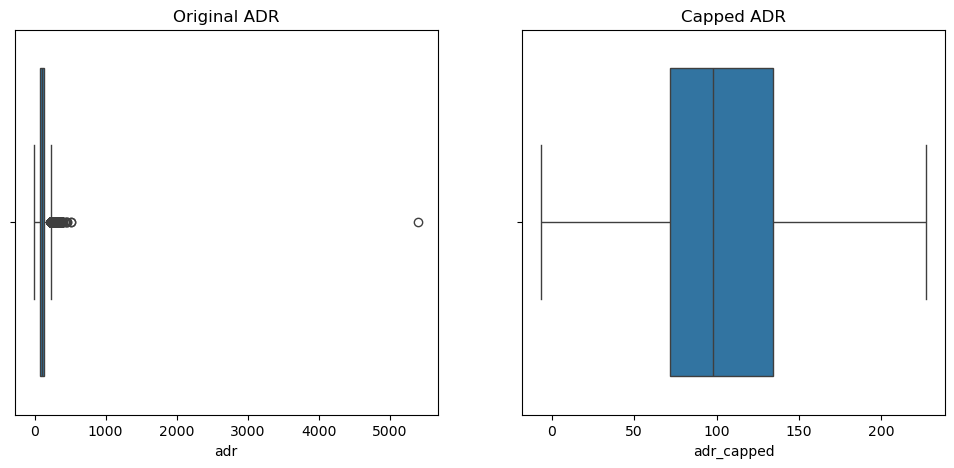

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['adr'])
plt.title("Original ADR")

plt.subplot(1,2,2)
sns.boxplot(x=df['adr_capped'])
plt.title("Capped ADR")

plt.show()

In [10]:
df['adr'] = df['adr_capped']

df.drop(
    columns=['adr_capped'],
    inplace=True
)

In [11]:
outliers_after = df[
    (df['adr'] < lower_bound) |
    (df['adr'] > upper_bound)
]

print(len(outliers_after))

0


In [12]:
import os

os.makedirs(
    r"C:\Users\Hp\Desktop\Travel-Tourism-Customer-Retention-Analysis\data\processed",
    exist_ok=True
)

In [14]:
df.to_csv(
    r"C:\Users\Hp\Desktop\Travel-Tourism-Customer-Retention-Analysis\data\processed\hotel_bookings_final_cleaned.csv",
    index=False
)

In [15]:
import os

os.listdir(
    r"C:\Users\Hp\Desktop\Travel-Tourism-Customer-Retention-Analysis\data\processed"
)

['hotel_bookings_feature_engineered.csv', 'hotel_bookings_final_cleaned.csv']

## Findings

- ADR outliers were treated using Winsorization (capping).
- No records were removed from the dataset.
- Extreme ADR values above 227 were capped.
- The dataset remains complete with 87,370 records.
- The cleaned ADR variable is now suitable for EDA and predictive modeling.

## Day 5 Conclusion

ADR outliers were successfully treated using the IQR-based capping approach.

This method preserves all booking records while reducing the influence of extreme values.

The resulting dataset is now ready for final validation and exploratory analysis in Day 6.